# TalentPulse Salary Prediction
## Phase 1 - Data Validation, Cleaning, and Exploratory Data Analysis

**Your role:** Machine Learning Engineer at TalentPulse Analytics.

**Business objective:** prepare a trustworthy modeling table for a supervised regression pipeline that predicts average salary and can be evaluated against the legacy benchmark of **$18,500 MAE**.

This is a teaching notebook. Read the short explanation above each code cell, run cells in order, and pause at each checkpoint before moving on.

## Goal

By the end of this notebook, you will be able to:

1. validate the shape, schema, grain, and quality of the jobs dataset;
2. explain why missing target values must not be median-imputed;
3. standardize local-country salaries to a common USD target;
4. identify salary-unit problems, invalid experience values, and near-duplicate postings;
5. parse skills and create transparent engineered features;
6. answer the case study's first EDA questions with reproducible charts;
7. export leakage-safe training candidates, an unlabeled scoring pool, and a review queue.

## Setup

### Data architecture

We use a small medallion-style architecture:

- **Bronze:** the unchanged raw CSV.
- **Silver:** all records, cleaned and enriched, with quality flags.
- **Gold:** task-specific training and scoring tables.

Keeping these layers separate makes the work reproducible and prevents accidental edits to the raw evidence.

In [1]:
from pathlib import Path
import ast
import hashlib
import json
import platform
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy import stats

# Find the project root whether Jupyter starts from the root or notebooks/.
search_locations = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
PROJECT_ROOT = next(
    path for path in search_locations
    if (path / "data" / "raw" / "jobs_dataset.csv").exists()
)

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "jobs_dataset.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

BLUE = "#2563EB"
GOLD = "#D97706"
PINK = "#DB2777"
OLIVE = "#657A2E"
CHARCOAL = "#273444"
LIGHT_GREY = "#E5E7EB"

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Raw source: {RAW_DATA_PATH}")

Python: 3.13.9
pandas: 2.3.3
Project root: C:\Users\tatej\OneDrive\Documents\Final Capstone Project
Raw source: C:\Users\tatej\OneDrive\Documents\Final Capstone Project\data\raw\jobs_dataset.csv


## Steps

### 1. Load the Bronze data

The intended grain is **one row per scraped job posting**, identified by `job_id`. We read the source as UTF-8 and leave the Bronze file unchanged.

In [2]:
raw = pd.read_csv(RAW_DATA_PATH, encoding="utf-8")
print(f"Rows: {raw.shape[0]:,}")
print(f"Columns: {raw.shape[1]}")
display(
    raw[
        [
            "job_id", "job_title", "company", "country", "job_level",
            "is_remote", "salary_avg", "has_salary"
        ]
    ].head(5)
)

Rows: 4,653
Columns: 17


,job_id,job_title,company,country,job_level,is_remote,salary_avg,has_salary
0,5710345523,data scientist,Empnéo ICT,India,Mid,False,NaN,False
1,5676535670,data scientist,ADM,India,Mid,False,NaN,False
2,5705677339,data scientist,v4c.ai,India,Mid,False,NaN,False
3,5689758521,data scientist,Kotak Mahindra Bank,India,Mid,False,NaN,False
4,5709942304,data scientist,Whitefield Careers,India,Mid,False,NaN,False


### 2. Validate the schema and grain

A data contract protects downstream work from silent schema changes. We also test `job_id` uniqueness and exact-row duplication.

In [3]:
EXPECTED_COLUMNS = [
    "job_id", "job_title", "company", "location", "salary_min",
    "salary_max", "description", "country", "search_keyword",
    "experience_required", "degree_required", "skills", "num_skills",
    "job_level", "is_remote", "salary_avg", "has_salary"
]

schema_check = pd.DataFrame(
    {
        "expected": EXPECTED_COLUMNS,
        "present": [column in raw.columns for column in EXPECTED_COLUMNS],
        "dtype": [
            str(raw[column].dtype) if column in raw.columns else "MISSING"
            for column in EXPECTED_COLUMNS
        ],
    }
)

print(f"Expected shape from case study: 4,653 rows x 17 columns")
print(f"Observed shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"Unique job_id: {raw['job_id'].is_unique}")
print(f"Exact duplicate rows: {raw.duplicated().sum():,}")
display(schema_check)

Expected shape from case study: 4,653 rows x 17 columns
Observed shape: 4,653 rows x 17 columns
Unique job_id: True
Exact duplicate rows: 0


,expected,present,dtype
0,job_id,True,int64
1,job_title,True,object
2,company,True,object
3,location,True,object
4,salary_min,True,float64
5,salary_max,True,float64
6,description,True,object
7,country,True,object
8,search_keyword,True,object
9,experience_required,True,float64


### 3. Build a compact data-quality profile

We inspect completeness and cardinality before cleaning. Missingness in the target (`salary_avg`) is treated differently from missingness in input features.

In [4]:
quality_profile = pd.DataFrame(
    {
        "dtype": raw.dtypes.astype(str),
        "missing_count": raw.isna().sum(),
        "missing_pct": (100 * raw.isna().mean()).round(2),
        "distinct_count": raw.nunique(dropna=False),
    }
).sort_values(["missing_pct", "distinct_count"], ascending=[False, False])

display(quality_profile)

,dtype,missing_count,missing_pct,distinct_count
experience_required,float64,4166,89.53,43
salary_max,float64,2358,50.68,1832
salary_avg,float64,2354,50.59,1901
salary_min,float64,2354,50.59,1825
company,object,1,0.02,1852
job_id,int64,0,0.00,4653
description,object,0,0.00,3361
job_title,object,0,0.00,1513
location,object,0,0.00,833
skills,object,0,0.00,51


**Tutor note:** `experience_required` is missing for most rows, while a zero-length skills list may mean "the parser found nothing" rather than "the job requires no skills." We will preserve indicators for these conditions instead of pretending the values are fully observed.

### 4. Check duplicates at the business grain

`job_id` is unique, but repeated postings can still share the same title, company, location, and description. We create a normalized fingerprint. We do not automatically delete conflicting repeats because some share a description but contain different salary values; later, the fingerprint should be used as a grouping key during train/test splitting.

In [5]:
def normalize_text(series: pd.Series) -> pd.Series:
    return (
        series.fillna("")
        .astype(str)
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

fingerprint_text = pd.DataFrame(
    {
        column: normalize_text(raw[column])
        for column in ["job_title", "company", "location", "description"]
    }
).agg("|".join, axis=1)

raw["posting_fingerprint"] = fingerprint_text.map(
    lambda value: hashlib.sha1(value.encode("utf-8")).hexdigest()
)
raw["duplicate_group_size"] = (
    raw.groupby("posting_fingerprint")["job_id"].transform("size")
)

repeated = raw.loc[raw["duplicate_group_size"].gt(1)].copy()
repeat_summary = repeated.groupby("posting_fingerprint").agg(
    rows=("job_id", "size"),
    labeled_rows=("salary_avg", "count"),
    distinct_salaries=("salary_avg", "nunique"),
)

print(f"Rows in near-duplicate groups: {len(repeated):,}")
print(f"Near-duplicate groups: {len(repeat_summary):,}")
print(
    "Extra rows beyond one per fingerprint: "
    f"{(repeat_summary['rows'] - 1).sum():,}"
)
print(
    "Groups with conflicting non-null salaries: "
    f"{repeat_summary['distinct_salaries'].gt(1).sum():,}"
)
display(repeat_summary.value_counts().rename("groups").reset_index())

Rows in near-duplicate groups: 77
Near-duplicate groups: 33
Extra rows beyond one per fingerprint: 44
Groups with conflicting non-null salaries: 12


,rows,labeled_rows,distinct_salaries,groups
0,2,0,0,13
1,2,2,2,6
2,2,2,1,4
3,3,3,3,3
4,4,4,4,3
5,2,1,1,2
6,3,0,0,1
7,3,2,1,1


### 5. Decide how to handle missing salary targets

For supervised regression, `salary_avg` is the label the model must learn. Median-imputing a missing label would invent the correct answer and train the model to reproduce our guess.

Therefore:

- rows with a valid salary become **training candidates**;
- rows without a salary become the **scoring pool**;
- questionable salary records go to a **review queue**.

In [6]:
salary_availability = pd.crosstab(
    raw["has_salary"],
    raw["salary_avg"].notna().rename("salary_avg_present"),
    margins=True,
)
display(salary_availability)

print(f"Actual missing salary_avg values: {raw['salary_avg'].isna().sum():,}")
print(f"Rows where has_salary is False: {(~raw['has_salary']).sum():,}")
print(
    "Important discrepancy: four rows have salary_avg=10,000 even though "
    "has_salary is False and salary_max is missing."
)

salary_avg_present,False,True,All
has_salary,,,
False,2354,4,2358
True,0,2295,2295
All,2354,2299,4653


Actual missing salary_avg values: 2,354
Rows where has_salary is False: 2,358
Important discrepancy: four rows have salary_avg=10,000 even though has_salary is False and salary_max is missing.


### 6. Standardize salary currency

The source combines local-country salary scales. A raw value of 1,000,000 in India is not comparable with 1,000,000 in the USA. Since the business evaluates MAE in dollars, we create a 2024 USD target.

The fixed conversion table below uses **rounded 2024 official exchange rates, local currency units per US dollar**, from the [World Bank indicator PA.NUS.FCRF](https://data.worldbank.org/indicator/PA.NUS.FCRF?name_desc=true). Fixed, sourced rates make the notebook rerunnable. In production, this would be a versioned reference table.

In [7]:
COUNTRY_CURRENCY = {
    "USA": {"currency": "USD", "lcu_per_usd": 1.00},
    "UK": {"currency": "GBP", "lcu_per_usd": 0.78},
    "Canada": {"currency": "CAD", "lcu_per_usd": 1.37},
    "India": {"currency": "INR", "lcu_per_usd": 83.67},
    "Australia": {"currency": "AUD", "lcu_per_usd": 1.52},
}

currency_reference = (
    pd.DataFrame.from_dict(COUNTRY_CURRENCY, orient="index")
    .rename_axis("country")
    .reset_index()
)
display(currency_reference)

silver = raw.copy()
silver["currency"] = silver["country"].map(
    {country: values["currency"] for country, values in COUNTRY_CURRENCY.items()}
)
silver["lcu_per_usd"] = silver["country"].map(
    {country: values["lcu_per_usd"] for country, values in COUNTRY_CURRENCY.items()}
)

for source_column in ["salary_min", "salary_max", "salary_avg"]:
    silver[f"{source_column}_local"] = silver[source_column]
    silver[f"{source_column}_usd"] = (
        silver[source_column] / silver["lcu_per_usd"]
    )

country_salary_comparison = silver.groupby("country").agg(
    labeled_rows=("salary_avg", "count"),
    median_local_salary=("salary_avg_local", "median"),
    median_usd_salary=("salary_avg_usd", "median"),
).round(2)
display(country_salary_comparison)

,country,currency,lcu_per_usd
0,USA,USD,1.00
1,UK,GBP,0.78
2,Canada,CAD,1.37
3,India,INR,83.67
4,Australia,AUD,1.52


,labeled_rows,median_local_salary,median_usd_salary
country,,,
Australia,97,"157,500.00","103,618.42"
Canada,240,"110,000.00","80,291.97"
India,63,"1,050,000.00","12,549.30"
UK,949,"50,292.73","64,477.86"
USA,950,"126,332.88","126,332.88"


### 7. Validate salary bounds and create a review status

The dataset has no pay-period field. Some very small values look like hourly, daily, monthly, or placeholder amounts rather than annual salaries. We do not silently "fix" them.

We apply two transparent checks:

- **invalid_bounds:** target present but a bound is missing, non-positive, or reversed;
- **unit_review:** both bounds are structurally valid, but converted salary is outside a provisional annual plausibility range of $10,000-$500,000.

The lower threshold is a review rule, not a claim that every salary below $10,000 is impossible. This is especially important for India; the correct production fix is to collect salary currency and pay-period metadata.

In [8]:
has_target = silver["salary_avg_usd"].notna()
invalid_bounds = has_target & (
    silver["salary_min"].isna()
    | silver["salary_max"].isna()
    | silver["salary_min"].le(0)
    | silver["salary_max"].le(0)
    | silver["salary_min"].gt(silver["salary_max"])
)
unit_review = (
    has_target
    & ~invalid_bounds
    & ~silver["salary_avg_usd"].between(10_000, 500_000)
)
model_ready = has_target & ~invalid_bounds & ~unit_review

silver["salary_quality_status"] = np.select(
    [model_ready, unit_review, invalid_bounds],
    ["model_ready", "unit_review", "invalid_bounds"],
    default="unlabeled",
)

status_summary = (
    silver["salary_quality_status"]
    .value_counts()
    .rename_axis("status")
    .rename("rows")
    .to_frame()
)
status_summary["pct"] = (100 * status_summary["rows"] / len(silver)).round(2)
display(status_summary)

,rows,pct
status,,
unlabeled,2354,50.59
model_ready,2256,48.48
unit_review,28,0.60
invalid_bounds,15,0.32


### 8. Check target consistency and leakage

`salary_avg` is calculated from `salary_min` and `salary_max`. That makes both bounds - and any `salary_range` built from them - target-derived fields. They are useful for QA and descriptive analysis, but must not enter the prediction feature matrix.

In [9]:
both_bounds = silver["salary_min"].notna() & silver["salary_max"].notna()
recalculated_average = (silver["salary_min"] + silver["salary_max"]) / 2
formula_mismatch = (
    both_bounds
    & ~np.isclose(recalculated_average, silver["salary_avg"], equal_nan=True)
)

silver["salary_range_local"] = silver["salary_max"] - silver["salary_min"]
silver["salary_range_usd"] = (
    silver["salary_max_usd"] - silver["salary_min_usd"]
)

leakage_correlations = (
    silver.loc[model_ready, ["salary_avg_usd", "salary_min_usd", "salary_max_usd"]]
    .corr()["salary_avg_usd"]
    .rename("pearson_r")
    .to_frame()
)

print(f"Rows with both salary bounds: {both_bounds.sum():,}")
print(f"Rows where supplied average disagrees with the midpoint: {formula_mismatch.sum():,}")
display(leakage_correlations)

LEAKAGE_COLUMNS = {
    "salary_min", "salary_max", "salary_avg", "has_salary",
    "salary_min_local", "salary_max_local", "salary_avg_local",
    "salary_min_usd", "salary_max_usd", "salary_range_local",
    "salary_range_usd", "salary_quality_status"
}
print("Leakage policy:", sorted(LEAKAGE_COLUMNS))

Rows with both salary bounds: 2,295
Rows where supplied average disagrees with the midpoint: 0


,pearson_r
salary_avg_usd,1.00
salary_min_usd,0.99
salary_max_usd,0.99


Leakage policy: ['has_salary', 'salary_avg', 'salary_avg_local', 'salary_max', 'salary_max_local', 'salary_max_usd', 'salary_min', 'salary_min_local', 'salary_min_usd', 'salary_quality_status', 'salary_range_local', 'salary_range_usd']


### 9. Clean experience and engineer transparent features

The current experience parser sometimes captures company age or other numbers from the description (for example, 60 or 360 years). We keep values from 0 to 30 years, set the rest to missing, and add a missingness indicator.

We also parse the string-formatted skills list safely and create the four top-skill flags requested in the case study.

In [10]:
silver["experience_required_clean"] = silver["experience_required"].where(
    silver["experience_required"].between(0, 30)
)
silver["experience_missing"] = silver["experience_required_clean"].isna()
silver["experience_tier"] = pd.cut(
    silver["experience_required_clean"],
    bins=[-0.01, 2, 5, 10, np.inf],
    labels=["0-2 years", "3-5 years", "6-10 years", "11+ years"],
).astype("object").fillna("Missing")

def parse_skills(value):
    if not isinstance(value, str):
        return []
    try:
        parsed = ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return []
    if not isinstance(parsed, list):
        return []
    return sorted(
        {
            str(skill).strip().lower()
            for skill in parsed
            if str(skill).strip()
        }
    )

silver["skills_list"] = silver["skills"].map(parse_skills)
silver["skills_clean"] = silver["skills_list"].str.join("|")
silver["skills_extracted"] = silver["skills_list"].str.len().gt(0)

for skill in ["python", "sql", "spark", "aws"]:
    silver[f"skill_{skill}"] = silver["skills_list"].map(
        lambda values, skill_name=skill: skill_name in values
    )

silver["is_senior"] = silver["job_level"].isin(["Senior", "Lead"])
silver["salary_segment"] = np.where(
    silver["is_senior"], "Premium", "Standard"
)
silver["log_salary_avg_usd"] = np.where(
    silver["salary_avg_usd"].gt(0),
    np.log1p(silver["salary_avg_usd"]),
    np.nan,
)

feature_quality = pd.DataFrame(
    {
        "check": [
            "experience missing after range cleaning",
            "experience values above 30 moved to missing",
            "rows with extracted skills",
            "num_skills differs from parsed list length",
        ],
        "rows": [
            silver["experience_missing"].sum(),
            silver["experience_required"].gt(30).sum(),
            silver["skills_extracted"].sum(),
            (
                silver["num_skills"]
                != silver["skills_list"].str.len()
            ).sum(),
        ],
    }
)
display(feature_quality)

,check,rows
0,experience missing after range cleaning,4227
1,experience values above 30 moved to missing,61
2,rows with extracted skills,1409
3,num_skills differs from parsed list length,0


### EDA chart plan

The final surface is this Python notebook, so the charts use reproducible Matplotlib/Seaborn exports. The palette is single-root blue for simple comparisons, a blue/gold two-root policy for before/after or signed comparisons, and no more than five explicit colors when country or job-level identity matters.

| Analytical question | Chart family | Data sufficiency and grain | Output |
|---|---|---|---|
| Is the target observed evenly by country? | Bar | 5 countries; all 4,653 postings | `01_salary_label_coverage_by_country.png` |
| Is the model-ready target skewed? | Histogram pair | 2,256 labeled postings; one posting per row | `02_salary_distribution_and_log.png` |
| Does log transformation improve normality? | Q-Q pair | 2,256 labeled postings | `03_salary_qq_before_after_log.png` |
| Which numeric candidates have the strongest linear relationship? | Signed horizontal bar | 9 features; pair counts retained | `04_numeric_feature_correlations.png` |
| How does salary spread differ by country and level? | Grouped boxplot | 15 observed country-level combinations; support table retained | `05_salary_by_country_and_job_level.png` |
| How do standardized role-family medians compare by country? | Grouped bar | 22 observed role-country combinations; missing combinations stay absent | `06_salary_by_role_family_and_country.png` |

### 10. EDA - missing target coverage

**Analytical question:** Is the labeled sample representative across countries?

The chart uses five country categories and shows the percentage of postings with a non-null `salary_avg`. Large differences indicate that target missingness is not random and may limit generalization.

,country,total_postings,labeled_postings,coverage_pct
0,UK,949,949,100.00
1,USA,950,950,100.00
2,Canada,935,240,25.67
3,Australia,903,97,10.74
4,India,916,63,6.88


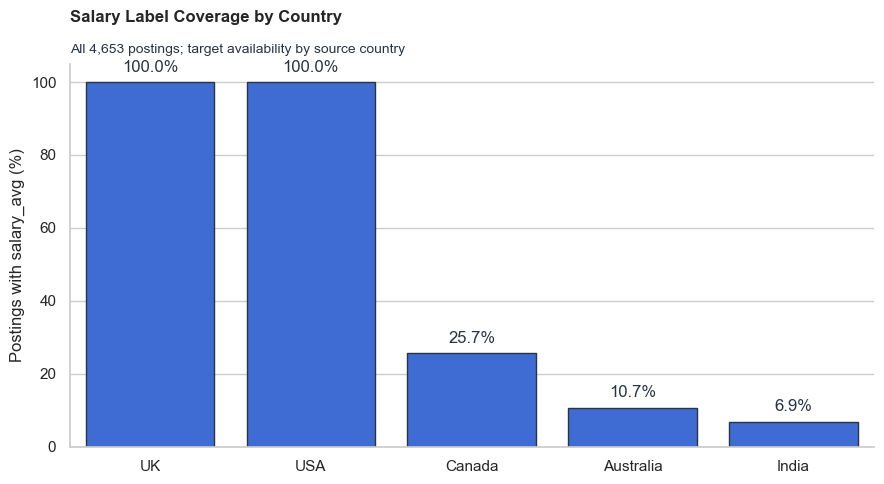

In [11]:
coverage_by_country = (
    silver.groupby("country")
    .agg(total_postings=("job_id", "size"), labeled_postings=("salary_avg", "count"))
    .assign(coverage_pct=lambda frame: 100 * frame["labeled_postings"] / frame["total_postings"])
    .sort_values("coverage_pct", ascending=False)
    .reset_index()
)
display(coverage_by_country.round(2))

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=coverage_by_country,
    x="country",
    y="coverage_pct",
    color=BLUE,
    edgecolor=CHARCOAL,
    ax=ax,
)
ax.set_title(
    "Salary Label Coverage by Country",
    loc="left",
    weight="bold",
    pad=30,
)
ax.set_xlabel("")
ax.set_ylabel("Postings with salary_avg (%)")
ax.set_ylim(0, 105)
for patch, value in zip(ax.patches, coverage_by_country["coverage_pct"]):
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        color=CHARCOAL,
    )
ax.text(
    0,
    1.02,
    "All 4,653 postings; target availability by source country",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=10,
    color=CHARCOAL,
)
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "01_salary_label_coverage_by_country.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

### 11. EDA - target distribution and log transformation

**Analytical question:** What is the distribution of `salary_avg`, and does a log transform reduce skew?

We use only `model_ready` USD targets so the distribution is on one currency scale and excludes records already routed for unit review.

,version,rows,mean,median,skewness
0,salary_avg_usd,2256,"100,856.34","87,591.24",1.12
1,log1p(salary_avg_usd),2256,11.39,11.38,-0.24


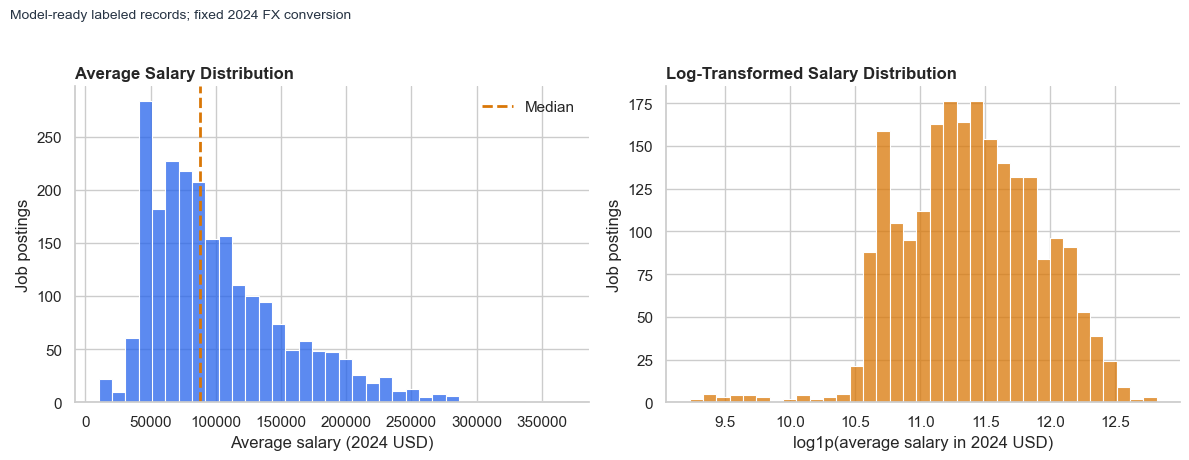

In [12]:
training_candidates = silver.loc[
    silver["salary_quality_status"].eq("model_ready")
].copy()

target_skew = training_candidates["salary_avg_usd"].skew()
log_target_skew = training_candidates["log_salary_avg_usd"].skew()

distribution_summary = pd.DataFrame(
    {
        "version": ["salary_avg_usd", "log1p(salary_avg_usd)"],
        "rows": [len(training_candidates), len(training_candidates)],
        "mean": [
            training_candidates["salary_avg_usd"].mean(),
            training_candidates["log_salary_avg_usd"].mean(),
        ],
        "median": [
            training_candidates["salary_avg_usd"].median(),
            training_candidates["log_salary_avg_usd"].median(),
        ],
        "skewness": [target_skew, log_target_skew],
    }
)
display(distribution_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(
    data=training_candidates,
    x="salary_avg_usd",
    bins=35,
    color=BLUE,
    edgecolor="white",
    ax=axes[0],
)
axes[0].axvline(
    training_candidates["salary_avg_usd"].median(),
    color=GOLD,
    linewidth=2,
    linestyle="--",
    label="Median",
)
axes[0].set_title("Average Salary Distribution", loc="left", weight="bold")
axes[0].set_xlabel("Average salary (2024 USD)")
axes[0].set_ylabel("Job postings")
axes[0].legend(frameon=False)

sns.histplot(
    data=training_candidates,
    x="log_salary_avg_usd",
    bins=35,
    color=GOLD,
    edgecolor="white",
    ax=axes[1],
)
axes[1].set_title("Log-Transformed Salary Distribution", loc="left", weight="bold")
axes[1].set_xlabel("log1p(average salary in 2024 USD)")
axes[1].set_ylabel("Job postings")

for axis in axes:
    sns.despine(ax=axis)
fig.suptitle(
    "Model-ready labeled records; fixed 2024 FX conversion",
    x=0.01,
    y=1.02,
    ha="left",
    fontsize=10,
    color=CHARCOAL,
)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_salary_distribution_and_log.png", dpi=160, bbox_inches="tight")
plt.show()

### 12. EDA - Q-Q plots before and after transformation

A Q-Q plot compares the target quantiles with a theoretical normal distribution. Straighter points mean closer normality. Tree models do not require a normal target, but a log target can help linear-model residual behavior and reduce the influence of high salaries.

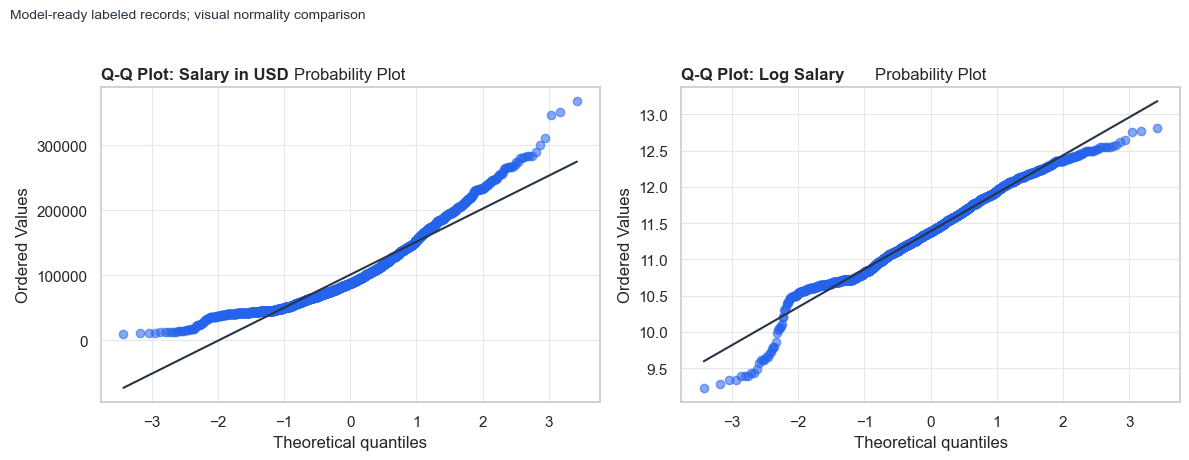

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

stats.probplot(
    training_candidates["salary_avg_usd"],
    dist="norm",
    plot=axes[0],
)
axes[0].set_title("Q-Q Plot: Salary in USD", loc="left", weight="bold")

stats.probplot(
    training_candidates["log_salary_avg_usd"],
    dist="norm",
    plot=axes[1],
)
axes[1].set_title("Q-Q Plot: Log Salary", loc="left", weight="bold")

for axis in axes:
    axis.get_lines()[0].set_markerfacecolor(BLUE)
    axis.get_lines()[0].set_markeredgecolor(BLUE)
    axis.get_lines()[0].set_alpha(0.55)
    axis.get_lines()[1].set_color(CHARCOAL)
    axis.grid(color=LIGHT_GREY, linewidth=0.8)

fig.suptitle(
    "Model-ready labeled records; visual normality comparison",
    x=0.01,
    y=1.02,
    ha="left",
    fontsize=10,
    color=CHARCOAL,
)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_salary_qq_before_after_log.png", dpi=160, bbox_inches="tight")
plt.show()

### 13. EDA - Pearson correlations with candidate numeric features

Pearson correlation applies to numeric variables and measures a linear relationship. We report pair counts because `experience_required_clean` is very sparse.

The salary bounds are intentionally absent from this table: their very high correlation is mechanical target leakage, not predictive insight.

,feature,pearson_r,pair_count
0,skills_extracted_int,0.36,2256
1,num_skills,0.27,2256
2,skill_python,0.10,2256
3,is_senior_int,0.10,2256
4,skill_sql,0.03,2256
5,skill_spark,0.03,2256
6,is_remote_int,-0.02,2256
7,experience_required_clean,-0.01,49
8,skill_aws,-0.01,2256


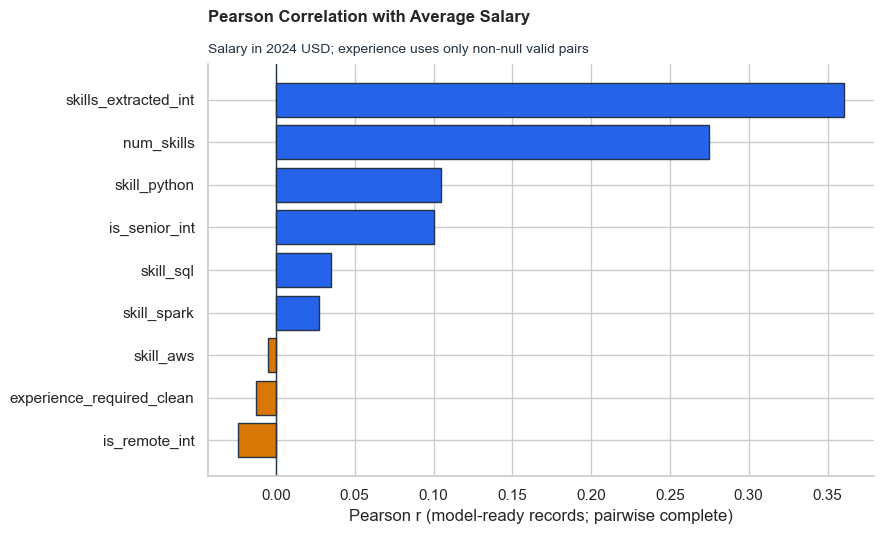

In [14]:
training_candidates["is_remote_int"] = training_candidates["is_remote"].astype(int)
training_candidates["is_senior_int"] = training_candidates["is_senior"].astype(int)
training_candidates["skills_extracted_int"] = (
    training_candidates["skills_extracted"].astype(int)
)

correlation_features = [
    "num_skills",
    "experience_required_clean",
    "is_remote_int",
    "is_senior_int",
    "skills_extracted_int",
    "skill_python",
    "skill_sql",
    "skill_spark",
    "skill_aws",
]

correlation_rows = []
for feature in correlation_features:
    pair = training_candidates[["salary_avg_usd", feature]].dropna()
    correlation_rows.append(
        {
            "feature": feature,
            "pearson_r": pair["salary_avg_usd"].corr(pair[feature]),
            "pair_count": len(pair),
        }
    )

target_correlations = (
    pd.DataFrame(correlation_rows)
    .sort_values("pearson_r", key=lambda values: values.abs(), ascending=False)
    .reset_index(drop=True)
)
display(target_correlations.round(4))

chart_data = target_correlations.sort_values("pearson_r")
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = [GOLD if value < 0 else BLUE for value in chart_data["pearson_r"]]
ax.barh(
    chart_data["feature"],
    chart_data["pearson_r"],
    color=colors,
    edgecolor=CHARCOAL,
)
ax.axvline(0, color=CHARCOAL, linewidth=1)
ax.set_title(
    "Pearson Correlation with Average Salary",
    loc="left",
    weight="bold",
    pad=30,
)
ax.set_xlabel("Pearson r (model-ready records; pairwise complete)")
ax.set_ylabel("")
ax.text(
    0,
    1.02,
    "Salary in 2024 USD; experience uses only non-null valid pairs",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=10,
    color=CHARCOAL,
)
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "04_numeric_feature_correlations.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

### 14. EDA - salary by country and job level

**Analytical question:** How does average salary vary across `country` and `job_level`?

The grouped boxplots compare distributions in 2024 USD. Always read a boxplot with sample sizes: the labeled sample is much smaller for India, Australia, Canada, Junior, and Lead roles.

,country,job_level,postings,median_salary_usd,mean_salary_usd
2,Australia,Senior,19,"141,118.42","130,107.34"
0,Australia,Lead,3,"138,157.89","152,192.98"
1,Australia,Mid,66,"100,328.95","102,830.18"
3,Canada,Lead,12,"96,596.72","110,698.87"
5,Canada,Senior,70,"94,160.58","102,818.41"
4,Canada,Mid,148,"72,901.46","79,526.41"
7,India,Senior,1,"21,513.09","21,513.09"
6,India,Mid,38,"17,628.78","21,434.46"
9,UK,Lead,51,"88,125.15","92,797.61"
11,UK,Senior,111,"85,608.65","89,831.92"


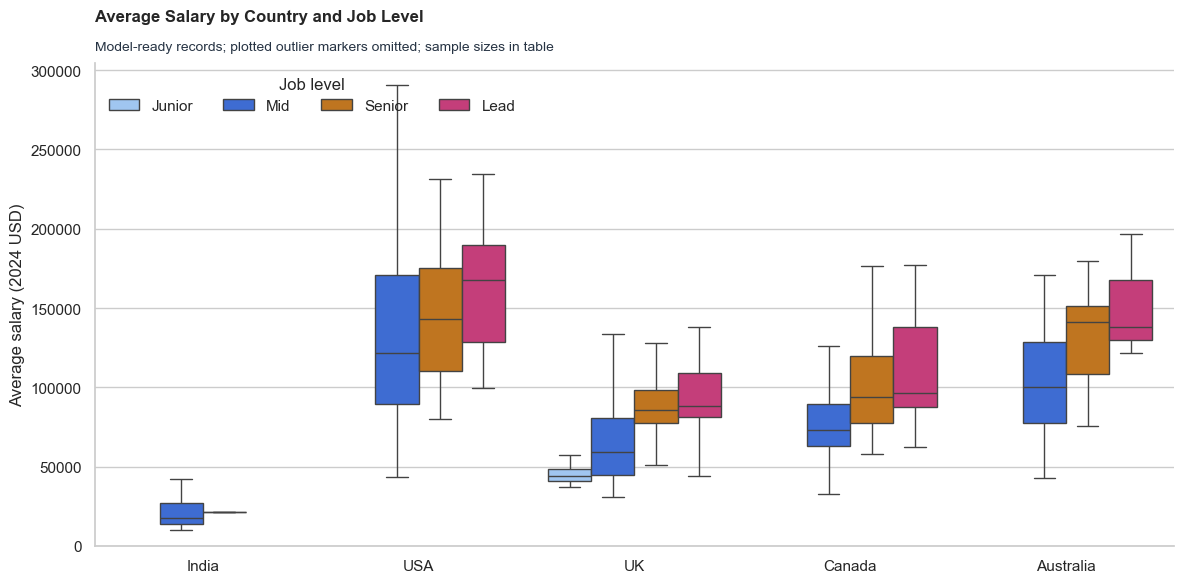

In [15]:
group_summary = (
    training_candidates.groupby(["country", "job_level"], observed=True)
    .agg(
        postings=("job_id", "size"),
        median_salary_usd=("salary_avg_usd", "median"),
        mean_salary_usd=("salary_avg_usd", "mean"),
    )
    .reset_index()
    .sort_values(["country", "median_salary_usd"], ascending=[True, False])
)
display(group_summary.round(2))

level_order = ["Junior", "Mid", "Senior", "Lead"]
palette = {
    "Junior": "#93C5FD",
    "Mid": BLUE,
    "Senior": GOLD,
    "Lead": PINK,
}

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=training_candidates,
    x="country",
    y="salary_avg_usd",
    hue="job_level",
    hue_order=level_order,
    palette=palette,
    showfliers=False,
    linewidth=1,
    ax=ax,
)
ax.set_title(
    "Average Salary by Country and Job Level",
    loc="left",
    weight="bold",
    pad=30,
)
ax.set_xlabel("")
ax.set_ylabel("Average salary (2024 USD)")
ax.set_ylim(bottom=0)
ax.legend(title="Job level", frameon=False, ncol=4, loc="upper left")
ax.text(
    0,
    1.02,
    "Model-ready records; plotted outlier markers omitted; sample sizes in table",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=10,
    color=CHARCOAL,
)
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "05_salary_by_country_and_job_level.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

### 15. EDA - salary by standardized role family

The raw `job_title` has more than 1,500 categories, so a grouped chart would be unreadable and unstable. For the first baseline, `search_keyword` is a defensible five-category role family. We keep raw titles for later text/NLP feature work.

,search_keyword,country,postings,median_salary_usd
21,machine learning engineer,USA,190,"194,676.74"
16,data scientist,USA,190,"146,248.84"
12,data engineer,USA,190,"130,635.07"
18,machine learning engineer,Canada,48,"120,802.92"
9,data engineer,Australia,23,"118,421.05"
13,data scientist,Australia,12,"111,842.11"
0,business analyst,Australia,35,"105,263.16"
17,machine learning engineer,Australia,1,"101,973.68"
5,data analyst,Australia,17,"94,071.71"
8,data analyst,USA,190,"92,854.99"


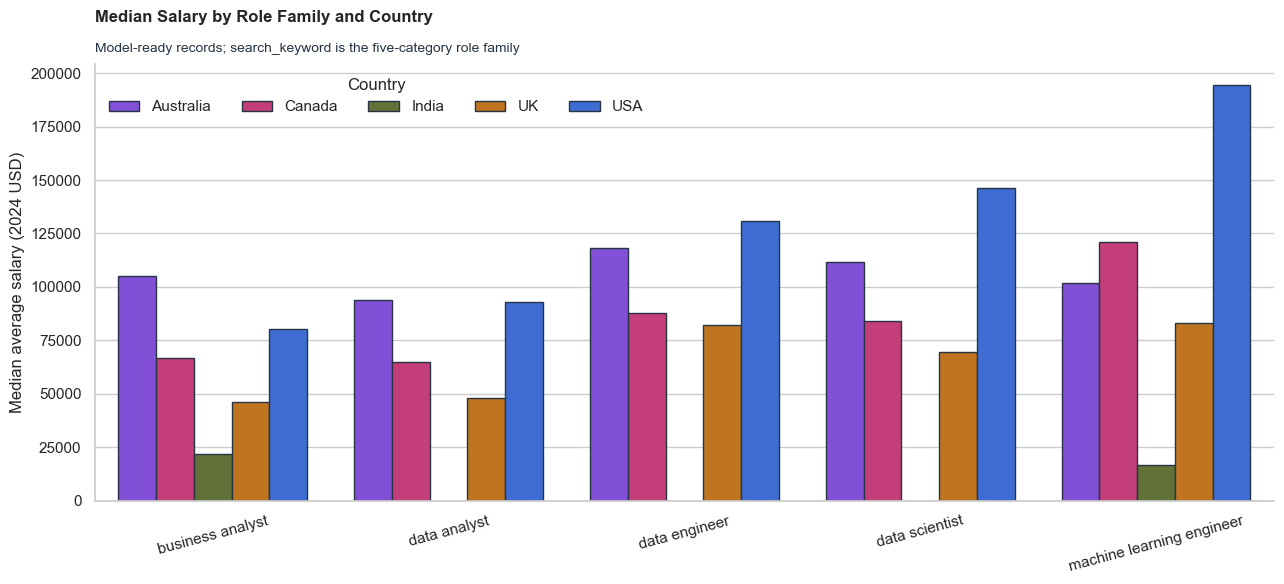

In [16]:
role_country_summary = (
    training_candidates.groupby(["search_keyword", "country"], observed=True)
    .agg(
        postings=("job_id", "size"),
        median_salary_usd=("salary_avg_usd", "median"),
    )
    .reset_index()
)
display(role_country_summary.sort_values("median_salary_usd", ascending=False).round(2))

country_palette = {
    "USA": BLUE,
    "UK": GOLD,
    "Canada": PINK,
    "India": OLIVE,
    "Australia": "#7C3AED",
}
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(
    data=role_country_summary,
    x="search_keyword",
    y="median_salary_usd",
    hue="country",
    palette=country_palette,
    edgecolor=CHARCOAL,
    errorbar=None,
    ax=ax,
)
ax.set_title(
    "Median Salary by Role Family and Country",
    loc="left",
    weight="bold",
    pad=30,
)
ax.set_xlabel("")
ax.set_ylabel("Median average salary (2024 USD)")
ax.tick_params(axis="x", rotation=15)
ax.legend(title="Country", frameon=False, ncol=5, loc="upper left")
ax.text(
    0,
    1.02,
    "Model-ready records; search_keyword is the five-category role family",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=10,
    color=CHARCOAL,
)
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "06_salary_by_role_family_and_country.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

### 16. EDA - category frequency and skill coverage

Before one-hot encoding, check whether categories are sufficiently represented. Junior roles are rare, but we keep all four levels for the first baseline and also create a Standard/Premium comparison field requested by the case study.

Skill flags are only as trustworthy as the parser coverage. A zero skill count often means no skills were extracted, so the `skills_extracted` indicator should accompany the flags.

In [17]:
level_frequency = (
    silver["job_level"]
    .value_counts()
    .rename_axis("job_level")
    .rename("rows")
    .to_frame()
    .assign(pct=lambda frame: 100 * frame["rows"] / len(silver))
)

skill_frequency = pd.DataFrame(
    {
        "skill": ["python", "sql", "spark", "aws"],
        "postings": [
            silver[f"skill_{skill}"].sum()
            for skill in ["python", "sql", "spark", "aws"]
        ],
    }
)
skill_frequency["pct_all_postings"] = (
    100 * skill_frequency["postings"] / len(silver)
)

print("Job-level frequency")
display(level_frequency.round(2))
print("Top-skill flag coverage")
display(skill_frequency.round(2))
print(
    f"Rows with at least one parsed skill: "
    f"{silver['skills_extracted'].sum():,} "
    f"({100 * silver['skills_extracted'].mean():.1f}%)"
)

Job-level frequency


,rows,pct
job_level,,
Mid,3442,73.97
Senior,846,18.18
Lead,293,6.30
Junior,72,1.55


Top-skill flag coverage


,skill,postings,pct_all_postings
0,python,277,5.95
1,sql,272,5.85
2,spark,85,1.83
3,aws,104,2.24


Rows with at least one parsed skill: 1,409 (30.3%)


## Checks

### 17. Run data contract assertions

These checks fail loudly if a future data refresh breaks an assumption. Passing checks do not prove the data is perfect; they prove that the specific contract below holds.

In [18]:
assert raw.shape[1] == 17 + 2, (
    "The working raw frame should contain the 17 source columns plus "
    "posting_fingerprint and duplicate_group_size."
)
assert set(EXPECTED_COLUMNS).issubset(raw.columns)
assert raw["job_id"].notna().all()
assert raw["job_id"].is_unique
assert formula_mismatch.sum() == 0
assert silver["lcu_per_usd"].notna().all()
assert silver["salary_quality_status"].notna().all()
assert (
    silver["salary_quality_status"].value_counts().sum() == len(silver)
)
assert training_candidates["salary_avg_usd"].notna().all()
assert training_candidates["salary_avg_usd"].between(10_000, 500_000).all()

print("All Phase 1 data contract checks passed.")

All Phase 1 data contract checks passed.


### 18. Export the Silver and Gold tables

The Gold training table intentionally excludes salary bounds, salary range, `has_salary`, and raw identifiers from the candidate feature list. We retain `job_id` and `posting_fingerprint` only as audit/splitting keys, not as model inputs.

In [19]:
CATEGORICAL_FEATURES = [
    "search_keyword",
    "country",
    "job_level",
    "degree_required",
    "experience_tier",
]
NUMERIC_FEATURES = [
    "num_skills",
    "experience_required_clean",
]
BINARY_FEATURES = [
    "is_remote",
    "experience_missing",
    "skills_extracted",
    "skill_python",
    "skill_sql",
    "skill_spark",
    "skill_aws",
]
SEGMENT_COLUMNS = ["is_senior", "salary_segment"]

AUDIT_COLUMNS = ["job_id", "posting_fingerprint", "duplicate_group_size"]
TARGET_COLUMNS = ["salary_avg_usd", "log_salary_avg_usd"]
GOLD_COLUMNS = (
    AUDIT_COLUMNS
    + SEGMENT_COLUMNS
    + CATEGORICAL_FEATURES
    + NUMERIC_FEATURES
    + BINARY_FEATURES
    + TARGET_COLUMNS
)

# Lists do not round-trip cleanly through CSV, so keep the pipe-separated form.
silver_export = silver.drop(columns=["skills_list"]).copy()
training_export = silver.loc[
    silver["salary_quality_status"].eq("model_ready"),
    GOLD_COLUMNS,
].copy()
scoring_export = silver.loc[
    silver["salary_quality_status"].eq("unlabeled"),
    (
        AUDIT_COLUMNS
        + SEGMENT_COLUMNS
        + CATEGORICAL_FEATURES
        + NUMERIC_FEATURES
        + BINARY_FEATURES
    ),
].copy()
review_export = silver.loc[
    silver["salary_quality_status"].isin(["invalid_bounds", "unit_review"]),
    [
        "job_id", "job_title", "company", "country", "salary_min_local",
        "salary_max_local", "salary_avg_local", "currency",
        "salary_avg_usd", "salary_quality_status"
    ],
].copy()

quality_metrics = pd.DataFrame(
    {
        "metric": [
            "source_rows",
            "source_columns",
            "missing_salary_avg",
            "model_ready_rows",
            "unlabeled_scoring_rows",
            "salary_review_rows",
            "exact_duplicate_rows",
            "near_duplicate_group_rows",
            "invalid_experience_over_30",
            "rows_with_parsed_skills",
        ],
        "value": [
            len(raw),
            len(EXPECTED_COLUMNS),
            raw["salary_avg"].isna().sum(),
            len(training_export),
            len(scoring_export),
            len(review_export),
            raw[EXPECTED_COLUMNS].duplicated().sum(),
            raw["duplicate_group_size"].gt(1).sum(),
            silver["experience_required"].gt(30).sum(),
            silver["skills_extracted"].sum(),
        ],
    }
)

silver_path = PROCESSED_DIR / "talentpulse_jobs_cleaned.csv"
training_path = PROCESSED_DIR / "talentpulse_training_candidates.csv"
scoring_path = PROCESSED_DIR / "talentpulse_scoring_pool.csv"
review_path = PROCESSED_DIR / "talentpulse_salary_review.csv"
quality_path = PROCESSED_DIR / "data_quality_summary.csv"

silver_export.to_csv(silver_path, index=False, encoding="utf-8")
training_export.to_csv(training_path, index=False, encoding="utf-8")
scoring_export.to_csv(scoring_path, index=False, encoding="utf-8")
review_export.to_csv(review_path, index=False, encoding="utf-8")
quality_metrics.to_csv(quality_path, index=False, encoding="utf-8")

outputs = pd.DataFrame(
    {
        "layer": ["Silver", "Gold", "Gold", "Review", "QA"],
        "rows": [
            len(silver_export),
            len(training_export),
            len(scoring_export),
            len(review_export),
            len(quality_metrics),
        ],
        "path": [
            silver_path,
            training_path,
            scoring_path,
            review_path,
            quality_path,
        ],
    }
)
display(outputs)

,layer,rows,path
0,Silver,4653,C:\Users\tatej\OneDrive\Documents\Final Capsto...
1,Gold,2256,C:\Users\tatej\OneDrive\Documents\Final Capsto...
2,Gold,2354,C:\Users\tatej\OneDrive\Documents\Final Capsto...
3,Review,43,C:\Users\tatej\OneDrive\Documents\Final Capsto...
4,QA,10,C:\Users\tatej\OneDrive\Documents\Final Capsto...


### 19. Phase 1 findings

Use the executed outputs above to support these conclusions:

- The source contains 4,653 postings and 17 original columns; `job_id` is complete and unique.
- The actual missing `salary_avg` count differs from the case-study wording because four incomplete-bound rows contain a placeholder-looking average.
- Salary label coverage varies sharply by country, so model evaluation must report country-level support and errors.
- Salaries require a common currency before a dollar MAE or RMSE is meaningful.
- Salary bounds and salary range are target leakage and belong only in QA/EDA.
- Experience extraction is sparse and contains implausible values; treat it as a weak feature until the parser is improved.
- The target remains right-skewed after quality filtering, while `log1p` greatly reduces the skew.
- Near-duplicate posting groups should remain together in train/test splits.

## Next Steps

Phase 2 will build the supervised regression pipeline:

1. use a group-aware 80/20 split based on `posting_fingerprint`;
2. preprocess numeric and categorical inputs with a `ColumnTransformer`;
3. establish an honest baseline (median predictor);
4. compare Linear/Ridge Regression, Random Forest, and Gradient Boosting;
5. tune the best model with 5-fold cross-validation;
6. evaluate RMSE, MAE, and R² on both dollar and log-target variants;
7. compare Standard vs Premium accuracy and inspect residuals by country and job level;
8. document the effect of missing-not-at-random salary labels and the provisional pay-period review rule.

**Pause here before modeling:** review `talentpulse_salary_review.csv`, especially India and low-rate records. A production model should not proceed without a confirmed salary currency/pay-period policy.